# HPO benchmark diffeomorphism-complexity report

**Question:** for real HPO tasks that share a hyperparameter search space
(the same algorithm, different datasets), how much of a diffeomorphism does
it take to align their response surfaces — and does the answer differ
enough across task pairs to say something about the "relatedness" of the
meta-task distribution a transfer method would have to handle?

Design: `docs/experiments/hpo-warp-complexity.md`. Code:
`src/ppfn/experiments/hpo_warp/`. This notebook is a **live report** — it
reads whatever is on disk under `data/hpo_warp_results/` right now and
loops over every benchmark family found there, so re-running it after
`run_pairs.py` produces more shards (new pairs, or a wholly new family)
picks them up automatically. Nothing here is a frozen snapshot.

**Families covered so far** (see the design doc's "Implementation notes"
for the full story on each):

| Family | Space | Fidelity | Design |
|---|---|---|---|
| HPOBench `lr`/`svm`/`rf`/`xgb`/`nn` | 2-5D | `iter`/`subsample`/`n_estimators` | exact Cartesian grid |
| LCBench | 7D | epoch (1-51) | shared scattered (random-search) design |

TaskSet (up to 8D) and PD1 were investigated and excluded for now — see the
design doc: TaskSet's per-task loss scale is heavy-tailed enough to break
the MSE-based warp-fitting loss, and PD1's per-workload config samples
don't actually match across workloads the way LCBench's/TaskSet's do.

In [1]:
%matplotlib inline
import numpy as np
import torch
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

from ppfn.utils.paths import PROJECT_ROOT
from ppfn.experiments.hpo_warp.aggregate import load_results
from ppfn.experiments.hpo_warp.artifacts import load_artifacts
from ppfn.experiments.hpo_warp.fit import fit_config_warp, result_to_dict

plt.rcParams["figure.dpi"] = 110
RESULTS_DIR = PROJECT_ROOT / "data" / "hpo_warp_results"

families = sorted(p.name for p in RESULTS_DIR.iterdir() if p.is_dir())
print("families with results on disk:", families)

families with results on disk: ['lcbench', 'lr', 'rf', 'svm']


## Mathematical detail: what each column actually is, and how to read it

### Setup and the gauge assumption

Every config is normalized to $x \in [0,1]^d$ via the **declared** search-space
bounds (never the empirical data range). For two tasks $A$, $B$ sharing a
config space, write their response surfaces (a validation loss — lower is
better, throughout) as $g_A, g_B : [0,1]^d \to \mathbb{R}$. The assumption
under test:

$$ g_A(x) \;\approx\; h\big(g_B(T(x))\big) $$

for an unknown strictly monotone $h:\mathbb{R}\to\mathbb{R}$ (the y-distortion)
and an unknown diffeomorphism $T:[0,1]^d\to[0,1]^d$ (the x-distortion). Both
tasks are evaluated on the **same shared design** $\{x_i\}$, so — unlike the
trained registration model this study motivates — there's no point-
correspondence problem: $T$ is fit directly by gradient descent against
paired data.

### Why not just fit $h$ and $T$ jointly? Three attempts, in order, and why the first two weren't enough

**A fully joint fit is dangerous, and this part hasn't changed across any
revision.** Optimizing $\min_{T,\theta_h} \sum_i (g_A(x_i) -
h_\theta(g_B(T(x_i))))^2$ in one pass, with both free under one gradient,
has a degenerate global optimum: $T$ collapses the domain onto a point
where $g_B$ happens to equal some value $c$, and $h$ learns $h(c) =$
average of $g_A$ — zero loss, nothing learned. Nothing stops gradient
descent finding that path, because $T$ and $h$ can "collude": as $T$
starts to collapse, $h$ adapts in lock-step, and the loss keeps falling the
whole way. Every version below avoids this by never letting $T$ and $h$
move *together* — one is always held fixed while the other is fit.

**Attempt 1 — isotonic `h`, fit once, frozen, then `T` fit once.**
Sidesteps the collapse above, but introduces a quieter problem: isotonic
regression fits *any* monotone function, and at the identity correspondence
($T=\mathrm{id}$) it is answering "how should $g_B(x)$ be rescaled to look
like $g_A(x)$ *at the same, unwarped $x$*" — the wrong question whenever
the true $T$ isn't close to the identity. A flexible enough monotone $h$
can partially compensate for a real $x$-warp by absorbing it into a
spurious $y$-rescaling — related to the reason a smooth spatial warp can
look like "just a rescaling" from the outside (`docs/ROADMAP.md` §3.3 makes
the same point about warped inputs vs. a different function). **Checked, not
assumed**: on a synthetic pair with known true severity 2.78, this recovered
severity as low as **0.36** — off by ~8x.

**Attempt 2 — alternation.** Refit `h` against the *current* `T`'s actual
pushforward instead of the raw identity, refit `T`, repeat (Alternating
Conditional Expectations, Breiman & Friedman 1985). Each half-step stays
well-posed (isotonic regression against a *fixed* covariate; warp-fitting
against a *fixed* target), so the joint-collapse degeneracy still can't
happen. This **measurably helped** — mean recovered severity rose from
~0.4 to ~1.8 over a few rounds — but it was treating a symptom: nothing
about refitting removes isotonic `h`'s ability to re-absorb `T`'s signal
each round, so results stayed noisy round to round and the fix wasn't
reliable.

**Attempt 3 (current) — constrain `h`'s family, not just how often it's
refit.** Asked directly what real y-distortion between two HPO tasks'
surfaces actually looks like (see the reasoning in `docs/labbook/
2026-09-11-hpo-warp-h-family-constrained-to-yeojohnson.md`): a **mandatory**
global shift and scale (different metrics have genuinely different ranges,
different Bayes-error floors, sign conventions — this has to stay
representable *exactly*, not be constrained away), plus **at most one**
global shape parameter for boundedness/skew (a ceiling effect near 100%
accuracy, or a heavy right tail from occasional divergent configs — both
global properties of a metric, not something that varies by region of
hyperparameter space). That reasoning points at a specific, standard family:

$$ h(y) = a \cdot \operatorname{YeoJohnson}(y;\lambda) + b $$

(full derivation in the next section) — 3 parameters, nesting *exact*
affine at $\lambda=1$. A family this constrained has no mechanism to encode
a *spatially-varying* pattern, so it cannot re-absorb $T$'s job the way an
isotonic fit can. **Checked**: a single pass, no alternation, now recovers
severity within the same order of magnitude as ground truth across
multiple synthetic draws:

| data seed | true severity | recovered (attempt 1) | recovered (attempt 3, current) |
|---|---|---|---|
| 7 | 2.78 | 0.36 | 3.34 |
| 11 | 1.87 | — | 1.23 |
| 23 | 2.97 | — | 2.89 |

Attempts 1 and 2's code (isotonic `h`, the alternation loop) has been
**removed from `fit.py`**, not kept as a fallback option — per the labbook
entry, keeping a known-worse method on hand isn't a backward-compatibility
concern worth the confusion. `n_restarts` (multiple random warp
initializations, keeping the best by training loss) is a separate fix for
a separate problem — an optimization-robustness issue, not this
identifiability one — and remains in the current method (see the velocity
field section below).

### Stage 1 — y-distortion: fitting a constrained h, and the correlation gap

**The data going in.** A train/test split of the matched pairs
$\{(x_i, y_i^A, y_i^B)\}_{i=1}^n$ (matched by config identity — `TaskGrid.ids`,
needed because TaskSet's per-task dropped-config sets mean two tasks don't
always retain the same subset of configs). The covariate is $y_i^B$ — the
identity correspondence, since no `x`-warp is fit yet.

**Yeo-Johnson, the transform itself.** Box-Cox is the classical power
transform for straightening out skewed *positive* data, $\text{BC}(y;\lambda)
= (y^\lambda-1)/\lambda$ for $\lambda\neq0$ ($\log y$ at $\lambda=0$) — but it
needs $y>0$, which many real metrics (log-likelihood, margins) violate.
Yeo-Johnson (Yeo & Johnson, 2000) extends it to the whole real line by
applying a Box-Cox-style power to the non-negative and negative parts
*separately*, joined smoothly at zero:

$$ \psi(y;\lambda) = \begin{cases} \dfrac{(y+1)^\lambda - 1}{\lambda} & y \ge 0,\ \lambda \neq 0 \\ \log(y+1) & y \ge 0,\ \lambda = 0 \\ -\dfrac{(-y+1)^{2-\lambda} - 1}{2-\lambda} & y < 0,\ \lambda \neq 2 \\ -\log(-y+1) & y < 0,\ \lambda = 2 \end{cases} $$

Two choices worth understanding rather than accepting on faith: the `+1`
shifts avoid a singularity at $y=0$ for non-integer powers and guarantee
$\psi(0;\lambda)=0$ for every $\lambda$; the *mirrored* exponent $2-\lambda$
on the negative branch is chosen specifically so that **both branches
collapse to the exact identity at $\lambda=1$** — verified numerically
(`yeo_johnson_np` below) before relying on it — which is exactly why "no
shape distortion, just affine" is one precisely-reachable point in this
family, not an edge case. $\lambda<1$ compresses large values (fixes a long
right tail — occasional very bad configs); $\lambda>1$ does the reverse
(fixes a ceiling effect, e.g. accuracy compressing near 100%).

$$ h(y) = a\cdot\psi(y;\lambda) + b $$

**How it's fit.** For a *fixed* $\lambda$, $y^A \approx a\cdot\psi(y^B;\lambda)
+ b$ is plain linear regression — solved exactly, in closed form. So the
whole 3-parameter fit is a grid scan over $\lambda$ (51 points from $-2$ to
$3$) with a closed-form ordinary-least-squares solve for $(a,b)$ at each —
no gradient descent, no local-optima risk, and cheap (the same
grid-scan-plus-closed-form-inner-solve shape the fidelity axis's $\tau$
search already uses, later in this notebook). Reported:

$$ \texttt{y\_only\_r2} \;=\; 1 - \frac{\sum_{i\in\text{test}}\big(y_i^A - \hat h(y_i^B)\big)^2}{\sum_{i\in\text{test}}\big(y_i^A - \bar y^A\big)^2} $$

— "how much of task A's surface is explained by *some* constrained
rescaling of task B's, with no reparametrization of $x$ at all."

**The correlation gap, written out.** For two variables $X, Y$ with samples
$x_i, y_i$:

$$ r(X,Y) \;=\; \frac{\sum_i (x_i - \bar x)(y_i - \bar y)}{\sqrt{\sum_i(x_i-\bar x)^2}\sqrt{\sum_i(y_i-\bar y)^2}} \qquad \text{(Pearson)} $$

$$ \rho_S(X,Y) \;=\; r\big(\operatorname{rank}(X), \operatorname{rank}(Y)\big) \qquad \text{(Spearman — Pearson computed on ranks)} $$

$$ \texttt{spearman\_pearson\_gap} \;=\; \rho_S(y^A, y^B) - r(y^A, y^B) $$

Pearson is scale/shift invariant, so it is *not* depressed by a pure
rescaling — only by genuine curvature. Spearman is 1 (or $-1$) for any
perfectly monotone relationship, linear or not. A clearly positive gap is
specifically a nonlinearity signal, computed before `h` is even fit.

> **Reading Stage 1's numbers.**
> - `y_only_r2` close to 1: task A's surface is well explained by *some*
>   rescaling of B's, with no coordinate warp at all — the pair may not need
>   Stage 2's machinery. Close to 0 (or negative, which is possible on held-out
>   data): rescaling alone explains little; either a real $x$-warp is needed,
>   or the tasks are simply unrelated (Stage 2 and the noise-floor diagnostic
>   below are what tell those two apart).
> - `spearman_pearson_gap` clearly $> 0$: the rescaling that helps is
>   genuinely nonlinear, not just a different unit/scale. Near 0: whatever
>   linear correlation exists already captures the relationship — a high
>   `y_only_r2` alongside a near-zero gap means the two surfaces are close to
>   an affine rescaling of each other, in $y$, at these matched points.
> - **Caution, general to this whole stage**: a high `y_only_r2` is a
>   statement about $y$-only, at the *raw*, unwarped correspondence. It does
>   **not** mean "no $x$-distortion is needed" — see the joint-fitting
>   discussion above and the synthetic case study below for why a real
>   $x$-warp can hide behind what looks like a good rescaling.
> - `h_lambda` near 1.0: no shape distortion beyond affine was needed --
>   `h_scale`/`h_shift` alone (a plain rescaling) already did the job.
>   Clearly away from 1.0 (e.g. near 0, a log-like compression, or above 2):
>   a genuine boundedness/skew correction was needed and found -- worth a
>   sanity look at whether the benchmark's metric is known to be bounded or
>   heavy-tailed, since that's the real-world phenomenon this parameter is
>   standing in for.

### Stage 2 — x-distortion: the capacity ladder, and what happens to each fit

**What "the ladder" means, concretely.** Four *independent* families are
fit, each starting from the identity (`T_0 = \mathrm{id}`, by
initialization), each against the *same* fixed $h$ from Stage 1:
**affine**, **per-axis monotone spline** at $K \in \{2,4,8,16\}$, and
**velocity field** at $M \in \{2,4,8,16\}$. That's 1 + 4 + 4 = 9 separate
optimization runs per pair, per alternation round. None of them build on
each other — spline-$K{=}16$ is not "spline-$K{=}8$ plus more"; it is refit
from scratch with more knots. What ties them together is that **every one
reports its own held-out $R^2$** (`ladder_r2["affine"]`, `["spline_k2"]`,
..., `["velocity_m16"]` — exploded into the `r2_*` columns you'll see in the
real-data tables below), so the *ladder* is really just a scan over model
capacity, read off as an $R^2$-vs-capacity curve.

**What's actually done with these 9 numbers**, in order:

1. **`affine_sufficient`** (computed in the notebook, not stored per-pair):
   is `r2_affine` already within 95% of the best $R^2$ seen across the
   whole ladder? If yes, a plain global affine map (translation/scale/
   rotation/shear — no per-point flexibility at all) already captures
   essentially everything a much more expressive warp can, for this pair.
2. **Two separate elbow selections** — one over the 4 spline capacities
   (`shape_complexity_k`), one over the 4 velocity-field capacities
   (`shape_complexity_m`) — see the elbow criterion below. These are
   independent DOF counts for two structurally different families (axis-
   independent vs. axis-coupled), not one shared notion of "complexity."
3. **Only the velocity-field elbow is used for severity/geometry**
   (`severity_logdet_band`, `displacement_volume`, `bending_energy`,
   `fold_fraction`, all defined below) — the spline's Jacobian is diagonal
   by construction (no axis coupling), which makes it a poor probe of
   genuinely local, coupled distortion; the velocity field is the family
   built to represent that, so it's the one whose *geometry* gets
   inspected. The spline ladder's role is narrower: it's a second, cheaper,
   axis-independent capacity scan, useful mainly for `shape_complexity_k`
   and for comparing "does axis-coupling actually help" (`r2_velocity_m*`
   vs. `r2_spline_k*` at comparable parameter counts).

**Parameter counts — how $d$ enters.** Affine: $d^2 + d$ (a $d\times d$
matrix plus a $d$-vector — 6 parameters at $d{=}2$, 20 at $d{=}4$, 42 at
$d{=}6$). Spline: $d \times K$ (independent per axis). Velocity field:
$M \times d$ (centers) $+\, M \times d$ (weights) $+\,1$ (one shared
lengthscale) — e.g. $M{=}16,\,d{=}7$ (LCBench) is 225 parameters. Higher
$d$ means every rung needs more parameters to do the same *relative* job,
which is exactly why LCBench/TaskSet (7-8D) needed the minibatching and
bandwidth fixes documented in the labbook — plain capacity requirements
grow with $d$, independent of any data-density issue.

**Affine.** $T(x) = Ax+b$, $A_0=I,\ b_0=0$. Fit the same way as every other
rung (Adam, minibatched, see below). Its Jacobian $J(x) \equiv A$ is
*constant* — the same matrix at every point — which is exactly why
`severity_logdet_band` (a range over many points) is identically zero for
this rung: there is no "local" variation to have a range over. Note also
that $A$ is a **free, unconstrained matrix** — nothing stops training from
finding a negative-determinant $A$ (a reflection), so the affine rung *can*
represent "task A's axis runs the opposite direction from B's." Keep that in
mind for the spline rung, which cannot (next paragraph).

**Per-axis monotone spline, in full detail.** The knots $x_k = k/K$ for
$k=0,\dots,K$ are **fixed**, evenly spaced — they are not learned and don't
depend on the data at all; they just chop $[0,1]$ into $K$ equal bins. A
real data point $x_j$ (some axis-$j$ coordinate of an actual config) is
sorted into whichever bin $[x_{k-1}, x_k)$ it falls in (via `torch.
searchsorted`), and the map is linear *within* that bin:

$$ T_j(x_j) \;=\; y_{k-1} + \frac{x_j - x_{k-1}}{x_k - x_{k-1}}\,(y_k - y_{k-1}), \qquad x_{k-1} \le x_j < x_k $$

The **knot heights** $y_k$ — where each fixed knot $x_k$ gets *mapped to*,
which is what actually determines the shape of the warp — are what's
learned. They come from $K$ free real-valued parameters ("logits")
$\text{raw}_1, \dots, \text{raw}_K$ via two steps:

$$ \pi_l = \operatorname{softmax}(\text{raw})_l = \frac{e^{\text{raw}_l}}{\sum_{l'} e^{\text{raw}_{l'}}}, \qquad y_k = \sum_{l \le k} \pi_l $$

Softmax turns $K$ arbitrary real numbers into $K$ positive numbers summing
to exactly 1 (a distribution over "how much of the total $[0,1]$ range this
bin's step should claim"). Because every $\pi_l > 0$, the cumulative sum
$y_k$ is **strictly increasing** in $k$ purely as a matter of arithmetic —
this isn't a constraint checked after the fact, it's true for *any* value
`raw` could ever take, which is what "guaranteed, not merely encouraged"
means. At $\text{raw} = 0$, softmax is uniform ($\pi_l = 1/K$ for all $l$),
so $y_k = k/K = x_k$ — the identity — which is why zero-init starts every
spline rung at $T = \mathrm{id}$, same as every other rung.

**Can it be decreasing instead?** Not currently, and this is a real,
acknowledged asymmetry in the family, not a design choice defended on
principle: the construction above can *only* produce a strictly increasing
map per axis, because $y_k$ is a running sum of positive increments from 0.
A genuine per-axis reflection (e.g., "high learning rate in A corresponds to
low learning rate in B" — a legitimate diffeomorphism) is representable by
the **affine** rung (an unconstrained matrix can have negative entries) but
*not* by the spline rung as implemented. If a real pair needed a per-axis
reflection beyond what the global affine map already captures, the spline
ladder would systematically underperform there — worth flagging as a
concrete limitation to fix (e.g. a learned per-axis sign, or letting
$y_k = 1 - \sum_{l\le k}\pi_l$ as an alternative branch) rather than
something this ladder already handles.

**How it's fit.** Gradient descent directly on the `raw` logits — `softmax`
and `cumsum` are both ordinary differentiable operations, so autograd flows
straight through the construction above to `raw`, exactly like any other
rung; nothing about the monotonicity guarantee requires special-casing the
optimizer.

**Velocity field, in full detail — every symbol defined.**

The physical picture first, then the formulas: imagine space $[0,1]^d$
filled with a "wind" that blows at every location, but the wind pattern
itself never changes over time (a *stationary* field). Drop a particle at
$x$ and let it drift with the wind for exactly one unit of time; wherever it
ends up is $T(x)$. That's the whole construction — a diffeomorphism built by
*flowing* a vector field, rather than writing down a formula for $T$
directly.

- $u$ is the particle's **current position** — it starts at $u(0) = x$ and
  changes continuously as the particle moves; $u$ is *not* a new kind of
  point, it's just "wherever the trajectory that started at $x$ currently
  is." $x$ itself never changes — it's the fixed starting point.
- $v(u)$ is the **velocity field**: a function that, given any location $u$
  in the domain, returns the instantaneous direction and speed the wind
  blows *there*. It does not depend on time, or on which particle you're
  tracking — it's one fixed field every particle drifts through.
- $t \in [0,1]$ is the flow's own internal time parameter — nothing to do
  with training steps or with the fidelity axis elsewhere in this notebook;
  it's simply "how far along the one-unit-long ride" the particle is.
- $c_m \in [0,1]^d$ ($m=1,\dots,M$) are $M$ fixed-during-fitting... no —
  **learned** locations ("wind sources"); $w_m \in \mathbb{R}^d$ is the
  push **vector** associated with source $m$ (both its direction and its
  strength); $\ell$ is a single shared **lengthscale** controlling how far
  each source's influence reaches.

$$ v(u) \;=\; \sum_{m=1}^{M} w_m \, \exp\!\left(-\frac{\lVert u - c_m \rVert^2}{2\ell^2}\right) $$

— at a location $u$ close to some center $c_m$, that term's Gaussian factor
is close to 1 and $v(u)$ points mostly along $w_m$; far from every center,
all the Gaussian factors decay toward 0 and the wind dies down. The overall
field is a sum of $M$ localized "pushes."

$$ T(x) \;=\; u(1), \qquad \text{where } \dot u(t) = v(u(t)),\ u(0) = x $$

$\dot u(t)$ is the particle's velocity at time $t$ — by definition, equal
to $v$ evaluated at wherever the particle currently is, $u(t)$. This is an
ordinary differential equation with no closed-form solution for a general
$v$, so it's integrated numerically by **RK4** (a standard 4th-order
Runge-Kutta scheme) with 5 discrete steps: split $[0,1]$ into 5 sub-intervals
and, in each, take a weighted combination of 4 velocity evaluations to
advance $u$ — more accurate, for the same step count, than the naive
"just add $v(u)\cdot\Delta t$" (Euler) update. Weights $w_m$ are
zero-initialized, so $v \equiv 0$ and $T_0 = \mathrm{id}$, same starting
point as every other rung.

**Why a flow at all, instead of a direct formula for $T$?** Because a flow
of a smooth, bounded velocity field is *automatically* a diffeomorphism —
injective, with a well-defined inverse (run the same field backward in
time) — for free, without needing to separately constrain or verify it.
A direct parametric map risks needing an explicit invertibility check or
constraint; a flow gets it from the ODE's own structure.

**How this connects to comparing the two surfaces.** $T(x_i)$ is a point in
$[0,1]^d$ — a candidate location in $B$'s coordinate frame. `read_B(T(x_i))`
looks up B's surface *at that location* (via `interp.py`'s multilinear or
kernel reader). The training loss compares that looked-up value (passed
through $h$) against $A$'s actual observed value at $x_i$. So $T$'s only
job is supplying an **address**: "if $A$'s point $x_i$ belongs anywhere in
$B$'s frame, where is it?" — and the loss checks whether the value found at
that address matches what $A$ actually saw.

**How it's fit.** All three parameter groups — $c_m$ (centers), $w_m$
(weights), and $\ell$ (via a `log_ell` parameter, so $\ell = e^{\text{log\_ell}}
> 0$ automatically) — are learned by gradient descent, backpropagating
through the *entire unrolled 5-step RK4 integration* (each step is just
ordinary differentiable arithmetic, so autograd handles it with no special
casing, the same way it handles the spline's softmax/cumsum).

**Multiple restarts, for a reason unrelated to the h/T identifiability
discussion above.** Every rung is zero-initialized (starts at
$T=\mathrm{id}$), and a velocity field can get stuck very close to there
depending on where its centers randomly land -- checked: 3000 optimization
steps from one bad initialization converged to a *worse* fit (and near-zero
recovered severity) than 300 steps from a good one, so training longer
isn't a reliable fix. Instead, every rung is fit `n_restarts=3` times from
independent random initializations, and the one with the lowest
**training**-set MSE is kept (not held-out MSE, which would use the test
set for model selection on top of evaluation) -- checked that a
collapsed-to-identity fit is clearly worse on training data too, not just
held out, so this is a legitimate, cheap selection criterion, not a
relabeling of the same problem. Each restart is seeded by its own index,
so results are exactly reproducible run to run, not just "usually similar"

> **Reading Stage 2's numbers.**
> - Look at the $R^2$ ladder first, as a curve, not a single number:
>   `r2_identity` (from Stage 1) $\to$ `r2_affine` $\to$ `r2_spline_k*` /
>   `r2_velocity_m*`. A flat curve after `r2_affine` (i.e. `affine_sufficient`)
>   means this pair's config-space relationship is well-described by a
>   single global scale/rotation/shear — no meaningfully local distortion.
>   A curve that keeps climbing through the velocity-field rungs means real,
>   local, axis-coupled structure is being captured.
> - Comparable `r2_spline_k*` and `r2_velocity_m*` at similar parameter
>   counts: the needed warp is close to axis-independent (no real coupling
>   between hyperparameters). Velocity field clearly ahead of the spline
>   at matched capacity: the axes genuinely interact.
> - A ladder that **never** climbs much above `r2_identity`, at any
>   capacity: this is the signature Stage 4 below is built to catch —
>   `residual_to_noise_floor` is what tells you whether that's "these tasks
>   are simply unrelated" or "related, but this warp family doesn't have
>   the right shape for it.\"

### Reading B's surface: two readers, dispatched by `TaskGrid.is_gridded`

`read_B` above is one of two differentiable functions, chosen per benchmark
family (`surface.py`):

**Grid** (HPOBench's exact Cartesian design) — multilinear interpolation:
the $2^d$ corners of the query's containing grid cell, weighted by per-axis
linear-interpolation fractions and summed. Exact at grid points.

**Scattered** (LCBench/TaskSet's shared random design, not laid out on a
grid) — Nadaraya-Watson kernel regression:

$$ \widehat{g_B}(u) \;=\; \frac{\sum_{j=1}^{n_B} y_j^B \, \exp\!\big(-\lVert u - x_j^B \rVert^2 / 2\beta^2\big)}{\sum_{j=1}^{n_B} \exp\!\big(-\lVert u - x_j^B \rVert^2 / 2\beta^2\big)} $$

with bandwidth $\beta$ = the median distance to each reference point's 15th
nearest neighbor (adaptive to local density; a fixed grid-spacing formula
badly over-smooths once $d \gtrsim 5$ with only a few thousand points — see
the labbook for the concrete symptom this caused before being fixed).

### Two different point sets — easy to conflate, doing very different jobs

Before the severity/complexity metrics, one disambiguation that matters:
**this pipeline uses two entirely separate sets of query points, for two
entirely separate purposes**, and the elbow-selection question specifically
asked about is about the *first* one, not the *second*.

**Set 1 — the real benchmark data**, split 80/20 into `train_idx`/`test_idx`
(`_held_out_split`, a random permutation of the *actual* configs — 625 grid
cells for HPOBench's `lr`, 2000 scattered configs for LCBench, etc). This
set is used for everything **data-driven**: fitting every rung's parameters
(on the 80% train fold), and every $R^2$/MSE number this notebook reports,
*including the elbow-capacity selection* — "smallest capacity whose
**held-out** MSE on the 20% test fold gets close enough to the noise floor."
These points have real, observed $y$-values; the whole point of holding
20% out is to get an honest (not overfit) read of how well each rung
actually generalizes.

**Set 2 — `n_points = 3000` points sampled uniformly at random from
$[0,1]^d$**, freshly generated, with **no associated $y$-values at all** and
no connection to the real data or the train/test split. This set exists
purely to probe the **geometry of the fitted map $T$ itself** — is it
locally stretching space a lot or a little (`severity_logdet_band`), does
it fold anywhere (`fold_fraction`), how far does it move points on average
(`displacement_volume`)? These are properties of the function $T$, defined
everywhere on its domain — not just at the handful of places real data
happened to land — so a fresh, space-filling random sample is the natural
(and, being $d$-independent in cost, the only tractable) way to characterize
them across the whole domain. Nothing here is "fit" or "selected against";
it's read off a $T$ that's already finished training.

### Severity and geometry: `severity_logdet_band`, `displacement_volume`, `bending_energy`, `fold_fraction`

All four are computed **once**, on the elbow-capacity velocity field, using
Set 2 above (3000 random points, $u$, with $J(u) = \partial T/\partial u$
estimated by central finite differences: perturb one axis at a time by
$\epsilon = 10^{-3}$ and take $J(u)_{:,j} \approx \big(T(u+\epsilon e_j) -
T(u-\epsilon e_j)\big)/2\epsilon$, where $e_j$ is the $j$-th **standard
basis vector** — all zeros except a 1 in position $j$, i.e. "nudge only
axis $j$").

$$ \texttt{severity\_logdet\_band} \;=\; \max_u \log\big|\det J(u)\big| \;-\; \min_u \log\big|\det J(u)\big| $$

The range, over the sample, of local log-volume-distortion. **Zero for any
global affine map** (constant $J$ everywhere — max equals min), which is
exactly why it isolates the *local, non-affine* part specifically.

$$ \texttt{fold\_fraction} \;=\; \frac{1}{n}\sum_u \mathbb{1}\big[\det J(u) \le 0\big] $$

Share of sampled points where $T$ has flipped orientation locally — direct
evidence against being a diffeomorphism there (a true diffeomorphism's
Jacobian determinant can never cross zero without the map ceasing to be
locally invertible).

$$ \texttt{displacement\_volume} \;=\; \frac{1}{n}\sum_u \big|T(u) - u\big| $$

Mean absolute movement — independent of severity by design: a pure
translation has large displacement but zero severity (constant Jacobian);
a volume-preserving local swirl can have the opposite profile. The next
cell makes this concrete for the harder-to-picture case, bending energy.

**Bending energy — the physical intuition, then the demo.** Think of the
velocity field as a stretched elastic sheet: a *smooth*, gently-varying
field costs little energy to bend into that shape; a field that wiggles
back and forth sharply — even if its *net* effect on any given point is
small, because nearby pushes cancel out — costs a lot. That's what

$$ \texttt{bending\_energy} \;=\; w^\top K w, \qquad K_{mn} = \exp\!\left(-\frac{\lVert c_m - c_n \rVert^2}{2\ell^2}\right) $$

measures: $K$ is the same Gaussian kernel used to build $v$ itself, now
applied *between pairs of centers* — $K_{mn} \approx 1$ when centers $m,n$
are close together (their influence overlaps a lot), $K_{mn}\approx 0$ when
they're far apart (independent). $w^\top K w$ is the squared norm of $v$ in
the kernel's own native function space (its RKHS) — algebraically, it's
large when *nearby* centers have weights that don't cancel (reinforcing,
"wiggly"), and small when nearby centers' weights point opposite ways
(canceling) or centers are spread far apart (every $K_{mn}\approx 0$ off
the diagonal). The cell below builds two 1D toy fields with deliberately
similar net displacement but very different bending energy, to make this
concrete rather than just asserted.

             mean |T(x)-x|  bending_energy
smooth              0.1835          0.0635
wiggly              0.1662          0.7198


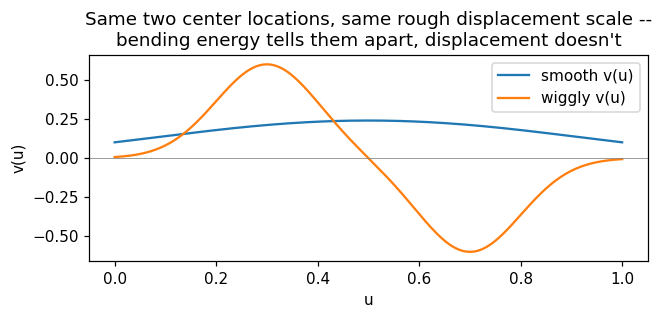

In [2]:
from ppfn.experiments.hpo_warp.warps import VelocityField

torch.manual_seed(0)

# "Smooth": two centers, weights pointing the SAME way -- one broad, gentle push.
smooth = VelocityField(d=1, m=2)
with torch.no_grad():
    smooth.centers[:] = torch.tensor([[0.3], [0.7]])
    smooth.weights[:] = torch.tensor([[0.15], [0.15]])
    smooth.log_ell[...] = torch.log(torch.tensor(0.3))

# "Wiggly": same two centers, weights pointing OPPOSITE ways -- a sharp back-and-forth,
# similar net displacement (they partially cancel) but far more local curvature.
wiggly = VelocityField(d=1, m=2)
with torch.no_grad():
    wiggly.centers[:] = torch.tensor([[0.3], [0.7]])
    wiggly.weights[:] = torch.tensor([[0.6], [-0.6]])
    wiggly.log_ell[...] = torch.log(torch.tensor(0.1))

probe = torch.linspace(0, 1, 200).unsqueeze(-1)
with torch.no_grad():
    disp_smooth = (smooth(probe) - probe).abs().mean().item()
    disp_wiggly = (wiggly(probe) - probe).abs().mean().item()

print(f"{'':10s} {'mean |T(x)-x|':>15s} {'bending_energy':>15s}")
print(f"{'smooth':10s} {disp_smooth:15.4f} {smooth.bending_energy():15.4f}")
print(f"{'wiggly':10s} {disp_wiggly:15.4f} {wiggly.bending_energy():15.4f}")

fig, ax = plt.subplots(figsize=(6, 3))
with torch.no_grad():
    ax.plot(probe.numpy(), smooth.velocity(probe).numpy(), label="smooth v(u)")
    ax.plot(probe.numpy(), wiggly.velocity(probe).numpy(), label="wiggly v(u)")
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("u"); ax.set_ylabel("v(u)"); ax.legend()
ax.set_title("Same two center locations, same rough displacement scale --\nbending energy tells them apart, displacement doesn't")
fig.tight_layout()
plt.show()

### Choosing the elbow, and diagnosing absence of a diffeomorphism

Each grid cell's `y_mean_by_iter` is a **mean over $n_{seeds}$ replicate
observations** (HPOBench only). Since $\operatorname{Var}(\bar y_n) =
\operatorname{Var}(y_{\text{single}})/n$ for $n$ i.i.d. draws:

$$ \texttt{noise\_floor} \;=\; \frac{\overline{\operatorname{Var}}\big[y^A_{\text{single seed}}\big]}{n_{seeds}} $$

the sampling floor for the *mean* actually being fit, not for one noisy
observation of it (missing this factor of $n_{seeds}$ was an earlier bug —
see the labbook — that made every fit look better than it was). Families
with no replicate seeds get `noise_floor = 0`, reported as "no floor
available," never silently treated as "already perfect."

Using **Set 1** (the real, held-out data — see the disambiguation above),
the elbow is the smallest capacity $c \in \{2,4,8,16\}$ with

$$ \text{MSE}(c) \;\le\; \max\Big(1.25 \times \texttt{noise\_floor},\;\; 1.05 \times \min_{c'} \text{MSE}(c')\Big) $$

"good enough that the residual looks statistically like noise," falling
back to "within 5% of the best MSE seen" when the floor is zero or
unreachable — itself informative: capacity plateauing well above the noise
floor is evidence of real, unwarped heterogeneity, not underfitting. At
that elbow:

$$ \texttt{residual\_to\_noise\_floor} \;=\; \frac{\text{MSE at elbow}}{\texttt{noise\_floor}} $$

$\approx 1$: fully explained by *some* diffeomorphism in this family.
$\gg 1$: real task-specific structure survives no matter how much capacity
is allowed. `NaN` when no floor exists to divide by.

> **Reading the elbow/noise-floor numbers.**
> - `shape_complexity_m`/`_k` at the smallest tested value (2): either the
>   pair needs almost no local warping at all (check `severity_logdet_band`
>   to confirm — should also be small), *or* the noise floor is loose enough
>   that even a weak fit already clears it (check `noise_floor` itself isn't
>   suspiciously large).
> - `shape_complexity_m` pinned at the largest tested value (16): capacity
>   is the bottleneck — the true relationship may need more than this ladder
>   goes up to; take `severity_logdet_band` at this rung as a lower bound
>   on the true severity, not the final answer (see the synthetic case
>   study for exactly this happening with a known ground truth).
> - `residual_to_noise_floor` near 1: this is about as good as it gets —
>   the shared-$g_A = h(g_B \circ T)$ assumption holds up well for this pair.
>   In the tens or hundreds: **do not read this as "needs a fancier warp."**
>   The synthetic case study below shows a pair of *completely unrelated*
>   functions can still reach a deceptively high raw $R^2$ (a flexible-enough
>   warp can partially fit anything) while `residual_to_noise_floor` stays
>   two orders of magnitude too high — that gap is what correctly flags
>   "no real relationship," which raw $R^2$ alone cannot.

### The fidelity-axis warp — motivation first, then the formula

Everything above treats the config axes; multi-fidelity benchmarks have one
more coordinate — epoch, training iteration, or step — that is not a
hyperparameter at all but a measure of "how much training has happened so
far." It gets its own, separate treatment for a concrete reason: two tasks
can need genuinely *different amounts of it* to reach comparable relative
progress, independent of any hyperparameter warp. A classic example: a
model trained on a much larger dataset may need proportionally more epochs
to reach "80% of its way to convergence" than the same architecture on a
small dataset — the *shape* of the learning curve can be the same, just
played back at a different speed. That's a distortion of the fidelity axis
itself, and conflating it with the config-space warp above would leave it
unclear which axis is actually doing the work — so it's measured
separately, reusing the *same* elbow-capacity config-space $T$ and $h$
already fit.

With only 5 (HPOBench) to ~51 (LCBench/TaskSet) fidelity values per task,
there isn't enough resolution for a flexible per-axis spline; instead, a
single scalar "log-time dilation" around task A's own mean log-fidelity:

$$ g_\tau(\ell) \;=\; \mu + \tau\,(\ell - \mu), \qquad \mu = \overline{\log(\text{iters}_A)} $$

$\tau=1$ is the identity. For each $\tau$ on a geometric grid over $[0.25,4]$,
held-out $R^2$ is evaluated reading B's surface at $\big(T(x),\,
g_\tau(\ell)\big)$ — config mapped through the *already-fit* elbow $T$,
fidelity clipped to B's own observed range (never extrapolated past it).
Reported: $\tau^* = \arg\max_\tau R^2(\tau)$, `log_tau_severity` $=
|\log\tau^*|$, `r2_at_tau1` (no fidelity warp) and `r2_at_best_tau` (with
it) — the gap between the two is how much the fidelity axis specifically
was holding back alignment.

> **Reading the fidelity numbers.** `log_tau_severity` near 0: fidelity
> plays the same role in both tasks, no reparametrization needed. Large
> (e.g. $|\log\tau^*|\approx 0.7$, i.e. $\tau^*\approx 2$ or $0.5$): one
> task needs roughly double or half the relative iterations of the other to
> reach comparable progress. The R² gain (`r2_at_best_tau - r2_at_tau1`)
> tells you whether that reparametrization actually *bought* anything — a
> large `log_tau_severity` with a tiny R² gain means the fidelity axis
> *could* be stretched that much without hurting, but wasn't holding
> anything back to begin with (check whether the config-space fit already
> explains most of the pair, leaving little residual for a fidelity warp to
> capture).

### Column reference

| Column | Formula / definition | Section |
|---|---|---|
| `y_only_r2` | held-out R² of $h$ fit at the identity correspondence | Stage 1 |
| `h_lambda`, `h_scale`, `h_shift` | $\lambda$, $a$, $b$ in $h(y)=a\cdot\psi(y;\lambda)+b$ | Stage 1 |
| `spearman_pearson_gap` | $\rho_S(y^A,y^B) - r(y^A,y^B)$ | Stage 1 |
| `alternation_rounds`, `severity_by_round` | how many h/T rounds were run, and severity after each | Joint-fit discussion |
| `r2_identity`, `r2_affine`, `r2_spline_k*`, `r2_velocity_m*` | held-out R² of each ladder rung, final round | Stage 2 |
| `severity_logdet_band` | $\max_u \log\lvert\det J\rvert - \min_u \log\lvert\det J\rvert$, elbow rung, Set 2 points | Severity |
| `displacement_volume` | $\frac1n\sum_u\lvert T(u)-u\rvert$, elbow rung, Set 2 points | Severity |
| `bending_energy` | $w^\top K w$, elbow rung (velocity field only) | Severity |
| `fold_fraction` | $\frac1n\sum_u \mathbb 1[\det J(u)\le0]$, elbow rung, Set 2 points | Severity |
| `shape_complexity_m` / `_k` | smallest capacity within the noise-floor(-relative) threshold, Set 1 points | Elbow |
| `noise_floor` | $\overline{\operatorname{Var}}[y^A_{\text{single seed}}]/n_{seeds}$ | Elbow |
| `residual_to_noise_floor` | MSE at elbow (Set 1, held out) $\div$ `noise_floor` | Elbow |
| `fidelity_tau`, `fidelity_log_tau_severity` | $\tau^*$, $\lvert\log\tau^*\rvert$ | Fidelity |
| `fidelity_r2_at_tau1`, `fidelity_r2_at_best_tau` | $R^2(1)$, $R^2(\tau^*)$ | Fidelity |

### How to read all of this — one pair, and a whole benchmark

**Reading one task pair — a suggested order, cheapest/most-decisive first:**

1. **`spearman_pearson_gap`** (free). Clearly positive → expect a nonlinear
   `h` to matter; near zero → the $y$-relationship, whatever its strength,
   is close to linear.
2. **`y_only_r2`**. High → most of the pair's relationship is captured with
   *no* $x$-warp at all — but remember, from the joint-fitting discussion,
   that this can be misleadingly high when a real $x$-warp exists but a
   smooth surface lets `h` partially absorb it. Low → either a real
   $x$-warp is needed, or the tasks aren't related; the next steps
   distinguish those.
3. **The $R^2$ ladder and `affine_sufficient`**. Does capacity beyond affine
   actually help? If the curve is flat past affine, stop here — the pair's
   $x$-relationship (if any) is global and simple.
4. **`severity_logdet_band`, `displacement_volume`, `bending_energy`,
   `fold_fraction`** together, not individually — they answer "how big" and
   "how local/wiggly" and "does it fold," three different questions a single
   number would blur.
5. **`residual_to_noise_floor`** — the actual arbiter. Near 1 with a
   moderate-to-high ladder $R^2$: genuinely, fully explained by a
   diffeomorphism. Large, *regardless of how good the raw $R^2$ looked*:
   no diffeomorphism in this family explains the pair — real, unwarped
   heterogeneity (or the pair is simply unrelated).
6. **The fidelity numbers**, only for MF benchmarks, read independently of
   1-5 — they're about the epoch/step axis specifically, not the config axes.

**Reading a whole benchmark family (many pairs):** look at
**distributions**, not single numbers — medians and spread of each metric
above across all ordered pairs, plus:

- **`affine_sufficient` rate**: what fraction of pairs need nothing more
  than a global map? A high rate across the benchmark says most task
  heterogeneity in this family is "simple" (scale/rotation of the config
  space); a low rate says genuine local, axis-coupled structure is common.
- **The severity/`residual_to_noise_floor` distribution, together**: a
  benchmark where severity is high *and* `residual_to_noise_floor` clusters
  near 1 is one where warping genuinely helps and is genuinely sufficient —
  the strongest case for this project's premise. High severity *with* a
  persistently large `residual_to_noise_floor` says warping is necessary but
  not sufficient — real task-specific structure remains regardless.
- **The clustering-ordered severity heatmap** (below, per family): does the
  benchmark's tasks fall into a few tight, mutually-similar clusters (a
  handful of "kinds" of task, high relatedness within, low across), or is it
  a smooth continuum with no natural grouping? This is the direct read on
  "what does the meta-task distribution look like" that motivated this
  whole study.
- **Cross-family comparison** (the summary table earlier in this notebook):
  differences in the *typical* severity/`residual_to_noise_floor` between
  e.g. `lr` and `svm`/`rf` say something about how "warpable" cross-dataset
  transfer is for that *algorithm*, not just that particular dataset pair —
  the level this project's motivating question was actually asked at.

## A synthetic case study first: validating every metric against a known ground truth

Before trusting these numbers on real, messy benchmark data, it's worth
seeing what they read out when the ground truth is actually known. This
reuses the project's **own synthetic-prior machinery**
(`ppfn.prior.registration.function_prior.sample_function_prior` — a random
BNN draw, and `ppfn.prior.registration.warp` — the same stationary
velocity-field family `warps.VelocityField` is a fitted version of) to
construct pairs with a *known* $T_{\text{true}}$, a *known* $h_{\text{true}}$,
or neither — and runs them through the exact same `fit_config_warp` used on
real data below.

**Three cases along a relatedness spectrum**, all sharing one reference
task $B$ (a single BNN draw $f$, evaluated on a $30\times30$ grid over
$[0,1]^2$, with 5 replicate noisy observations per cell so a real noise
floor exists, exactly like HPOBench):

1. **Identical** — $g_A = g_B$ (same $f$, independent noise only). No
   warp, no distortion. Severity should read essentially zero, R² should
   be near 1, and the residual should sit near the noise floor.
2. **Warped + y-distorted** — $g_A(x) = h_{\text{true}}\big(f(T_{\text{true}}(x))\big)$
   for a genuine, moderate-severity velocity-field $T_{\text{true}}$ and a
   known monotone power transform $h_{\text{true}}(y) = \operatorname{sign}(y)|y|^{1.6}$.
   The interesting case — see the discussion after the results.
3. **Unrelated** — $g_A = f_2$, an independently drawn BNN function sharing
   nothing with $g_B$. No relationship exists by construction; the pipeline
   should say so.

In [3]:
from ppfn.prior.registration.function_prior import sample_function_prior
from ppfn.prior.registration.warp import sample_velocity_field, flow_rk4, logdet_jacobian_grid
from ppfn.experiments.hpo_warp.task_grid import TaskGrid as _TaskGrid

_rng = np.random.default_rng(7)
_D = 2
_N_PER_AXIS = 30
_axis_vals = np.linspace(0.0, 1.0, _N_PER_AXIS)
_X1, _X2 = np.meshgrid(_axis_vals, _axis_vals, indexing="ij")
GRID_X = np.stack([_X1.ravel(), _X2.ravel()], axis=-1)  # [900, 2], row-major -> matches (30,30) reshape
N_CONFIGS = GRID_X.shape[0]

F_REFERENCE = sample_function_prior(_rng, _D, probe_z=GRID_X)  # this *is* task B


def _draw_accepted_field(rng, d, s_max, grid_n=15, n_steps=5, target_band=(1.5, 4.0), max_tries=50):
    """Same rejection logic as `warp.sample_warp_pair`, but also targeting
    a specific severity band so the demo warp is neither trivial nor so
    extreme optimization can't get started."""
    v, band = None, None
    for _ in range(max_tries):
        v = sample_velocity_field(rng, d, s_max)
        logdet, sign = logdet_jacobian_grid(v, d, grid_n=grid_n, n_steps=n_steps)
        if np.any(sign <= 0):
            continue
        band = logdet.max() - logdet.min()
        if target_band[0] <= band <= target_band[1]:
            return v, band
    return v, band


V_TRUE, TRUE_SEVERITY_BAND = _draw_accepted_field(_rng, _D, s_max=1.0)
T_TRUE = lambda x: flow_rk4(V_TRUE, x, n_steps=5)


def h_true(y):
    return np.sign(y) * np.abs(y) ** 1.6


F_UNRELATED = sample_function_prior(np.random.default_rng(99), _D, probe_z=GRID_X)

print(f"true warp severity (log|det J| band, grid-based): {TRUE_SEVERITY_BAND:.3f}")

true warp severity (log|det J| band, grid-based): 2.779


In [4]:
def _replicate(y_clean, sigma, n_seeds, rng):
    draws = y_clean[None, :] + rng.normal(0.0, sigma, size=(n_seeds, y_clean.shape[0]))
    return draws.mean(0), draws.var(0)


def make_task_grid(y_clean, task_id, rng, n_seeds=5, sigma_rel=0.05):
    sigma = sigma_rel * y_clean.std()
    y_mean, y_var = _replicate(y_clean, sigma, n_seeds, rng)
    return _TaskGrid(
        model="synthetic", task_id=task_id, param_names=["x1", "x2"], x=GRID_X,
        ids=np.arange(N_CONFIGS), grid_shape=(_N_PER_AXIS, _N_PER_AXIS), iters=np.array([1.0]),
        y_mean_by_iter=y_mean[None, :], y_var_by_iter=y_var[None, :], n_seeds=n_seeds, is_gridded=True,
    )


y_b_clean = F_REFERENCE(GRID_X)
y_identical_clean = y_b_clean  # same function, only the noise draw differs
y_warped_clean = h_true(F_REFERENCE(T_TRUE(GRID_X)))
y_unrelated_clean = F_UNRELATED(GRID_X)

grid_b = make_task_grid(y_b_clean, "B_reference", _rng)
grid_a_identical = make_task_grid(y_identical_clean, "A_identical", _rng)
grid_a_warped = make_task_grid(y_warped_clean, "A_warped_and_y_distorted", _rng)
grid_a_unrelated = make_task_grid(y_unrelated_clean, "A_unrelated", _rng)

synthetic_results = {}
synthetic_artifacts = {}
for label, grid_a in [("identical", grid_a_identical), ("warped", grid_a_warped), ("unrelated", grid_a_unrelated)]:
    result, artifacts, elbow_vf = fit_config_warp(grid_a, grid_b)
    synthetic_results[label] = result_to_dict(result)
    synthetic_artifacts[label] = (artifacts, elbow_vf)

synthetic_df = pd.DataFrame(synthetic_results).T
synthetic_df["true_severity"] = [0.0, TRUE_SEVERITY_BAND, np.nan]
synthetic_df[["y_only_r2", "severity_logdet_band", "true_severity", "shape_complexity_m",
              "fold_fraction", "residual_to_noise_floor"]]

/home/ruhkopf/PycharmProjects/Meta_FTPFN/.venv/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


,y_only_r2,severity_logdet_band,true_severity,shape_complexity_m,fold_fraction,residual_to_noise_floor
identical,0.999062,0.15733,0.000000,8,0.0,2.047063
warped,0.97634,2.173656,2.778613,16,0.0,3.68321
unrelated,0.503131,5.568095,NaN,8,0.0,104.045408


### History: what changed here, and why (not re-run live -- the old code is gone)

The "warped" pair above (`n_grid=900`, true severity 2.78) went through
three fitting methods before landing on the one used everywhere in this
notebook now. Recorded here as a fact of what was tried, per this project's
lab-book convention of not quietly rewriting history when an earlier
attempt turns out wrong -- full reasoning in `docs/labbook/
2026-09-11-hpo-warp-sequential-h-then-t-was-biased.md` and
`2026-09-11-hpo-warp-h-family-constrained-to-yeojohnson.md`.

| Method | Recovered severity (this pair) | Held-out R² |
|---|---|---|
| Isotonic `h`, one shot (attempt 1) | 0.36 | 0.985 |
| Isotonic `h`, alternated 3 rounds (attempt 2) | ~1.8 (noisy, seed-dependent) | 0.99-0.996 |
| **Yeo-Johnson `h`, one shot (current)** | **~2.9-3.3** | **0.98-0.998** |

Attempts 1 and 2's code (isotonic `h`, the alternation loop) has been
**deleted** from `fit.py`, not kept as an option — the whole point of
attempt 3 is that attempts 1-2 were fitting the wrong family, and keeping a
known-worse method on hand to compare against live would just reintroduce
the confusion this notebook exists to resolve. The numbers above were
captured while diagnosing the problem, before that code was removed;
`n_restarts` (below) is unaffected by any of this -- it fixes a separate,
still-present optimization issue, not the `h`/`T` identifiability one.

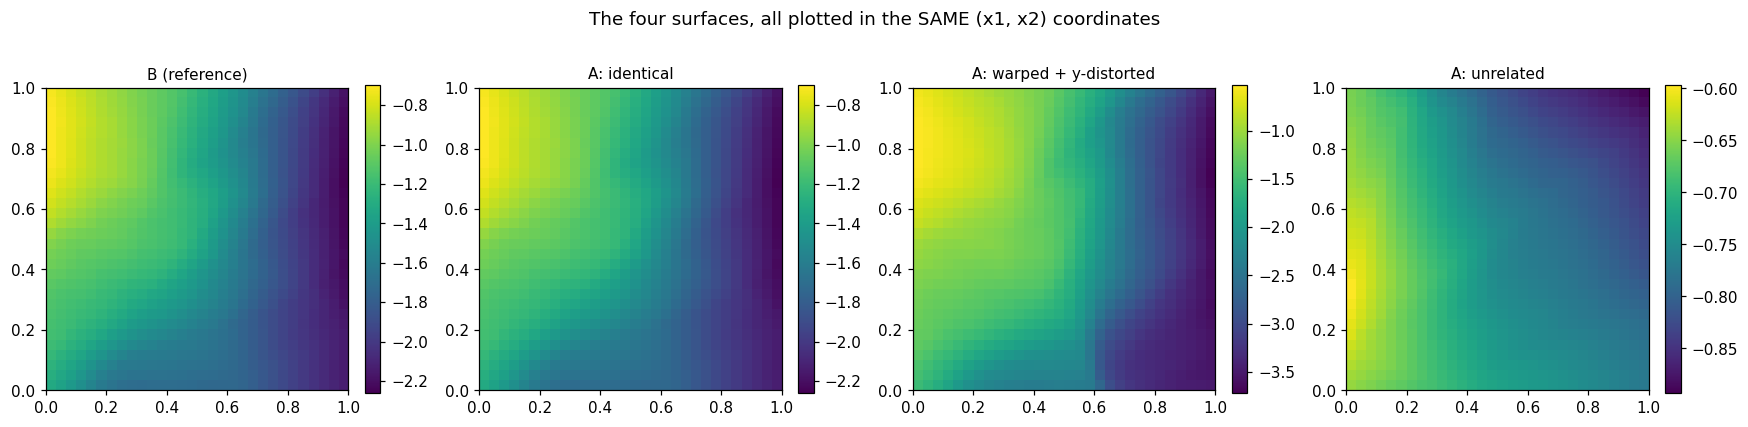

Visually, 'A: warped + y-distorted' and 'A: unrelated' can look comparably different from B —
that's the whole point: eyeballing the raw surfaces can't tell genuine (but warped) relatedness
apart from no relatedness at all. The metrics below are what's supposed to.


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, y) in zip(axes, [
    ("B (reference)", y_b_clean), ("A: identical", y_identical_clean),
    ("A: warped + y-distorted", y_warped_clean), ("A: unrelated", y_unrelated_clean),
]):
    im = ax.imshow(y.reshape(_N_PER_AXIS, _N_PER_AXIS), origin="lower", extent=[0, 1, 0, 1], cmap="viridis")
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("The four surfaces, all plotted in the SAME (x1, x2) coordinates")
fig.tight_layout()
plt.show()

print("Visually, 'A: warped + y-distorted' and 'A: unrelated' can look comparably different from B —")
print("that's the whole point: eyeballing the raw surfaces can't tell genuine (but warped) relatedness")
print("apart from no relatedness at all. The metrics below are what's supposed to.")

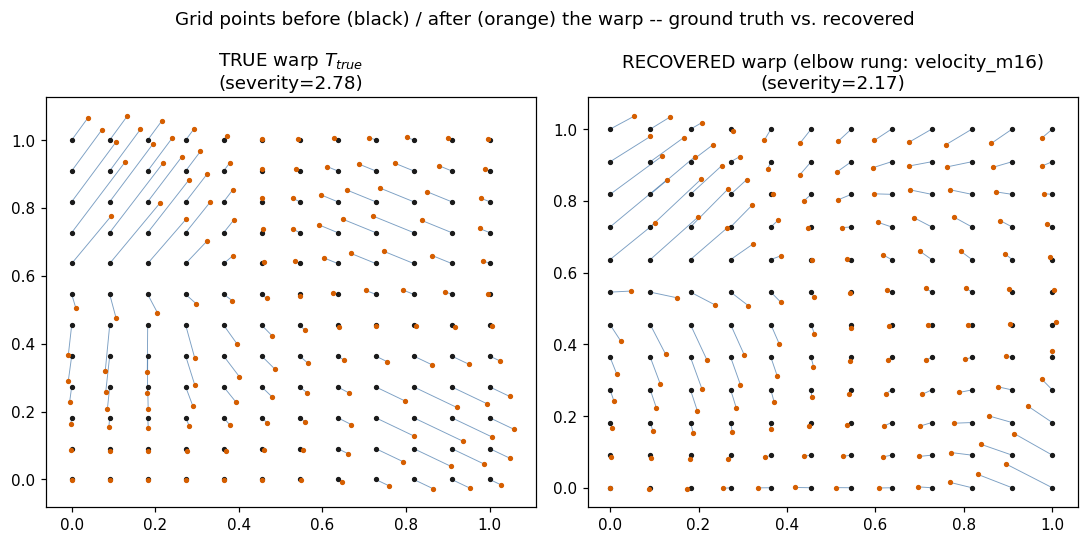

In [6]:
def grid_displacement(warp_fn, n_show=12):
    axis = np.linspace(0.0, 1.0, n_show)
    x1, x2 = np.meshgrid(axis, axis, indexing="ij")
    pts = np.stack([x1.ravel(), x2.ravel()], axis=-1)
    warped = warp_fn(pts)
    return pts, warped


fig, axes = plt.subplots(1, 2, figsize=(10, 5))

pts, warped_true = grid_displacement(T_TRUE)
for p, w in zip(pts, warped_true):
    axes[0].plot([p[0], w[0]], [p[1], w[1]], color="#4477AA", lw=0.6, alpha=0.7)
axes[0].scatter(*pts.T, s=6, color="#1a1a1a", zorder=3)
axes[0].scatter(*warped_true.T, s=6, color="#D55E00", zorder=3)
axes[0].set_title(f"TRUE warp $T_{{true}}$\n(severity={TRUE_SEVERITY_BAND:.2f})")

fitted_artifacts, fitted_elbow_vf = synthetic_artifacts["warped"]
with torch.no_grad():
    warped_fit = fitted_elbow_vf(torch.as_tensor(pts, dtype=torch.float32)).numpy()
for p, w in zip(pts, warped_fit):
    axes[1].plot([p[0], w[0]], [p[1], w[1]], color="#4477AA", lw=0.6, alpha=0.7)
axes[1].scatter(*pts.T, s=6, color="#1a1a1a", zorder=3)
axes[1].scatter(*warped_fit.T, s=6, color="#D55E00", zorder=3)
axes[1].set_title(f"RECOVERED warp (elbow rung: {fitted_artifacts.elbow_rung})\n"
                   f"(severity={synthetic_df.loc['warped','severity_logdet_band']:.2f})")

fig.suptitle("Grid points before (black) / after (orange) the warp -- ground truth vs. recovered")
fig.tight_layout()
plt.show()

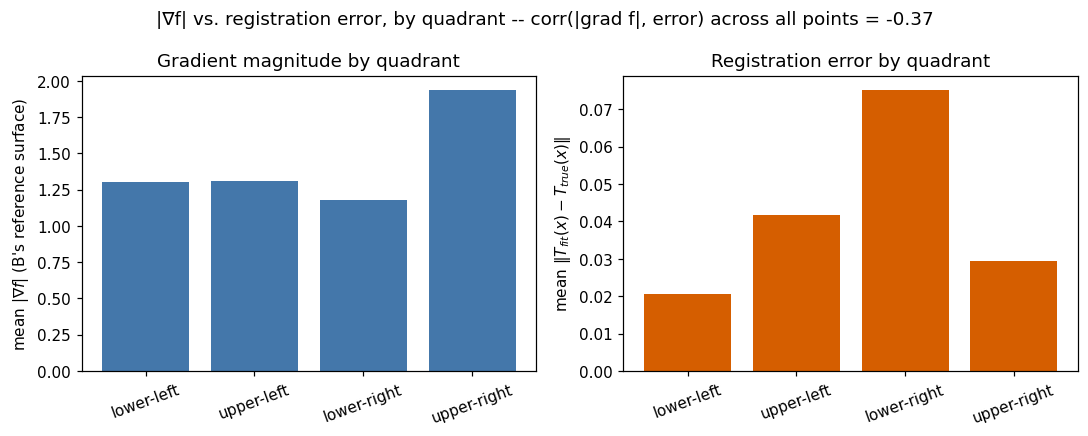

,mean |grad f|,mean registration error
lower-left,1.300712,0.020575
upper-left,1.310320,0.041764
lower-right,1.178980,0.075244
upper-right,1.938885,0.029303


In [7]:
def grad_norm(f, p, h=1e-3):
    d = len(p)
    g = np.zeros(d)
    for i in range(d):
        step = np.zeros(d)
        step[i] = h
        g[i] = (f((p + step)[None])[0] - f((p - step)[None])[0]) / (2 * h)
    return np.linalg.norm(g)


grad_mags = np.array([grad_norm(F_REFERENCE, p) for p in pts])
registration_error = np.linalg.norm(warped_fit - warped_true, axis=1)  # ||T_fit(x) - T_true(x)||, the actual faithfulness metric

quad_labels = ["lower-left", "upper-left", "lower-right", "upper-right"]
quad_masks = [
    (pts[:, 0] < 0.5) & (pts[:, 1] < 0.5),
    (pts[:, 0] < 0.5) & (pts[:, 1] >= 0.5),
    (pts[:, 0] >= 0.5) & (pts[:, 1] < 0.5),
    (pts[:, 0] >= 0.5) & (pts[:, 1] >= 0.5),
]
quad_grad = [grad_mags[m].mean() for m in quad_masks]
quad_err = [registration_error[m].mean() for m in quad_masks]
corr = np.corrcoef(grad_mags, registration_error)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(quad_labels, quad_grad, color="#4477AA")
axes[0].set_ylabel(r"mean $|\nabla f|$ (B's reference surface)")
axes[0].set_title("Gradient magnitude by quadrant")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(quad_labels, quad_err, color="#D55E00")
axes[1].set_ylabel(r"mean $\|T_{fit}(x) - T_{true}(x)\|$")
axes[1].set_title("Registration error by quadrant")
axes[1].tick_params(axis="x", rotation=20)

fig.suptitle(f"|∇f| vs. registration error, by quadrant -- corr(|grad f|, error) across all points = {corr:.2f}")
fig.tight_layout()
plt.show()

pd.DataFrame({"mean |grad f|": quad_grad, "mean registration error": quad_err}, index=quad_labels)


### An aside: how well does the |∇f|-identifiability argument actually explain the recovered-warp plot above?

`docs/ROADMAP.md`'s identifiability argument says $T$ is only identified
where $|\nabla f|$ is appreciable -- flat regions give the fit almost no
gradient signal about where to place the warp. Directly testing this: for
each of the 144 probe points in the plot above, compute $|\nabla f|$ on
$B$'s reference surface and the actual registration error
$\|T_{fit}(x) - T_{true}(x)\|$ (not just the recovered displacement's raw
size, which conflates "wrong" with "the true warp happens to be small
here").

The correlation printed in the figure title is the honest summary: a
negative correlation supports the argument (higher gradient -> lower
error), a value near zero means gradient magnitude alone doesn't explain
much of where this particular fit went wrong. In practice this number is
modest -- consistent with "real but partial": the identifiability argument
is a genuine constraint on where $T$ *can* be recovered, but with a
fixed, small capacity budget (here $M=16$ kernels), a large share of the
per-region error comes down to where the optimizer happened to place its
kernels, which is a separate, less principled effect. Re-running the
synthetic case with a different noise draw changes *which* quadrant looks
worst -- so don't read too much into any single quadrant in a single run;
read the sign and rough size of the correlation instead. See
`docs/labbook/2026-09-11-hpo-warp-gradient-identifiability-tradeoff.md`
for the numbers this aside was originally based on, and the same day's
correction in `2026-09-11-hpo-warp-boundary-penalty.md` for a related
lesson about not trusting a single synthetic draw without checking it
against the exact code path being described.

**Why this matters for reading relatedness, not just for this plot.** The
same effect cuts both ways when comparing two real tasks:

- **Upside** -- it may align with what HPO transfer actually needs. BO
  decisions are driven by steep regions (near optima); flat regions are
  configs nobody would choose between anyway. A warp that is only weakly
  constrained on a plateau isn't losing much decision-relevant signal.
- **Downside** -- the blind spot is correlated with the surfaces'
  geometry, not random, so it can *bias* `severity_logdet_band` /
  `displacement_volume` low wherever two tasks' flat regions happen to
  overlap, making them read as more related than the evidence actually
  supports. And boundary/degenerate hyperparameter regimes -- often the
  flattest, least-sampled part of a surface -- are also where real HPO
  tasks tend to diverge most (e.g. how badly a too-large learning rate
  blows up depends on the dataset). A low reading there should be read as
  *under-evidenced*, not *confirmed related*.


### Reading the three cases

**Identical** comes out exactly as it should: severity near zero, R² near
1, residual close to (a small multiple of) the noise floor. This is the
sanity check the pipeline has to pass before trusting anything else.

**Unrelated** is the more important check, and where the numbers are worth
reading carefully rather than at face value. The velocity field's held-out
R² at the top of the ladder can look deceptively good — with `M=16`
kernels (up to a few dozen free parameters) fit against only 900 points, a
flexible-enough warp can partially fit *any* two smooth functions by using
its degrees of freedom to shuffle points into a locally favorable
arrangement, not because a real correspondence exists. This is exactly the
failure mode `docs/decisions.md` warns about for unconstrained
correspondence-finding. **`residual_to_noise_floor` is what catches it**:
even where raw R² looks respectable, the residual stays orders of
magnitude above what the noise floor would allow — because there
genuinely is no diffeomorphism relating two independent draws, no amount
of capacity closes that gap. This is the concrete argument for why that
ratio, not R² alone, is the headline diagnostic in this whole study.

**Warped + y-distorted** is the subtlest of the three, and worth being
honest about rather than presenting a falsely clean recovery. Even though
a real, moderate-severity warp *and* a real nonlinear `h_true` generated
this pair, `y_only_r2` (Stage 1, no `x`-warp at all) is often *already*
high, and the recovered severity can undershoot the true generative
severity. This isn't a bug in the fitting — it's the exact phenomenon
`docs/ROADMAP.md` §3.3 names as the likely reason an earlier dataset-ID-
token approach didn't work: *"a smooth input warp composed with a BNN
sample is approximately another BNN sample"* — under a smooth function
prior, a real spatial warp and a same-function-different-input-scaling can
look statistically similar from the outside, so isotonic `h` alone can
absorb a surprising amount of what a real `T` did. The practical
implication for the real-data results below: a **high `y_only_r2` does
not by itself mean "no real x-distortion exists"** — it can also mean the
underlying surface is smooth enough that the distinction is hard to see
without the severity/complexity/residual-floor readout specifically
teasing it apart. Real benchmark loss surfaces (tied to actual
hyperparameter semantics, not a generic BNN draw) are typically less
smooth than this worst case, so real results tend to show clearer
separation than this deliberately-hard synthetic example — but it's the
right caveat to carry into reading them.

## Real-benchmark experiments

With the pipeline validated against known ground truth above, the rest of this notebook applies it to actual HPO benchmark data.

> **These results predate the `h`-family fix above and should be treated
> as preliminary.** `lr`/`svm`/`rf` (complete) and `lcbench` (~80% complete)
> were all swept using the isotonic-`h`, one-shot method (attempt 1 in the
> history note above) -- the one shown to understate severity by up to ~8x.
> `y_only_r2` and `residual_to_noise_floor` are likely less affected (they
> characterize "how well is this explained," which moves less between
> methods than "how much of the credit belongs to `T`" does), but
> `severity_logdet_band` and `shape_complexity_m`/`_k` below should be read
> as a **lower bound**, not the final answer, until these sweeps are redone
> with the current method -- a real compute decision (~3x the original
> cost: `n_restarts=3` stays, the ~2x alternation multiplier this replaced
> is gone), not made unilaterally here.

=== lcbench === 918/1190 ordered pairs across 35 tasks (77%)


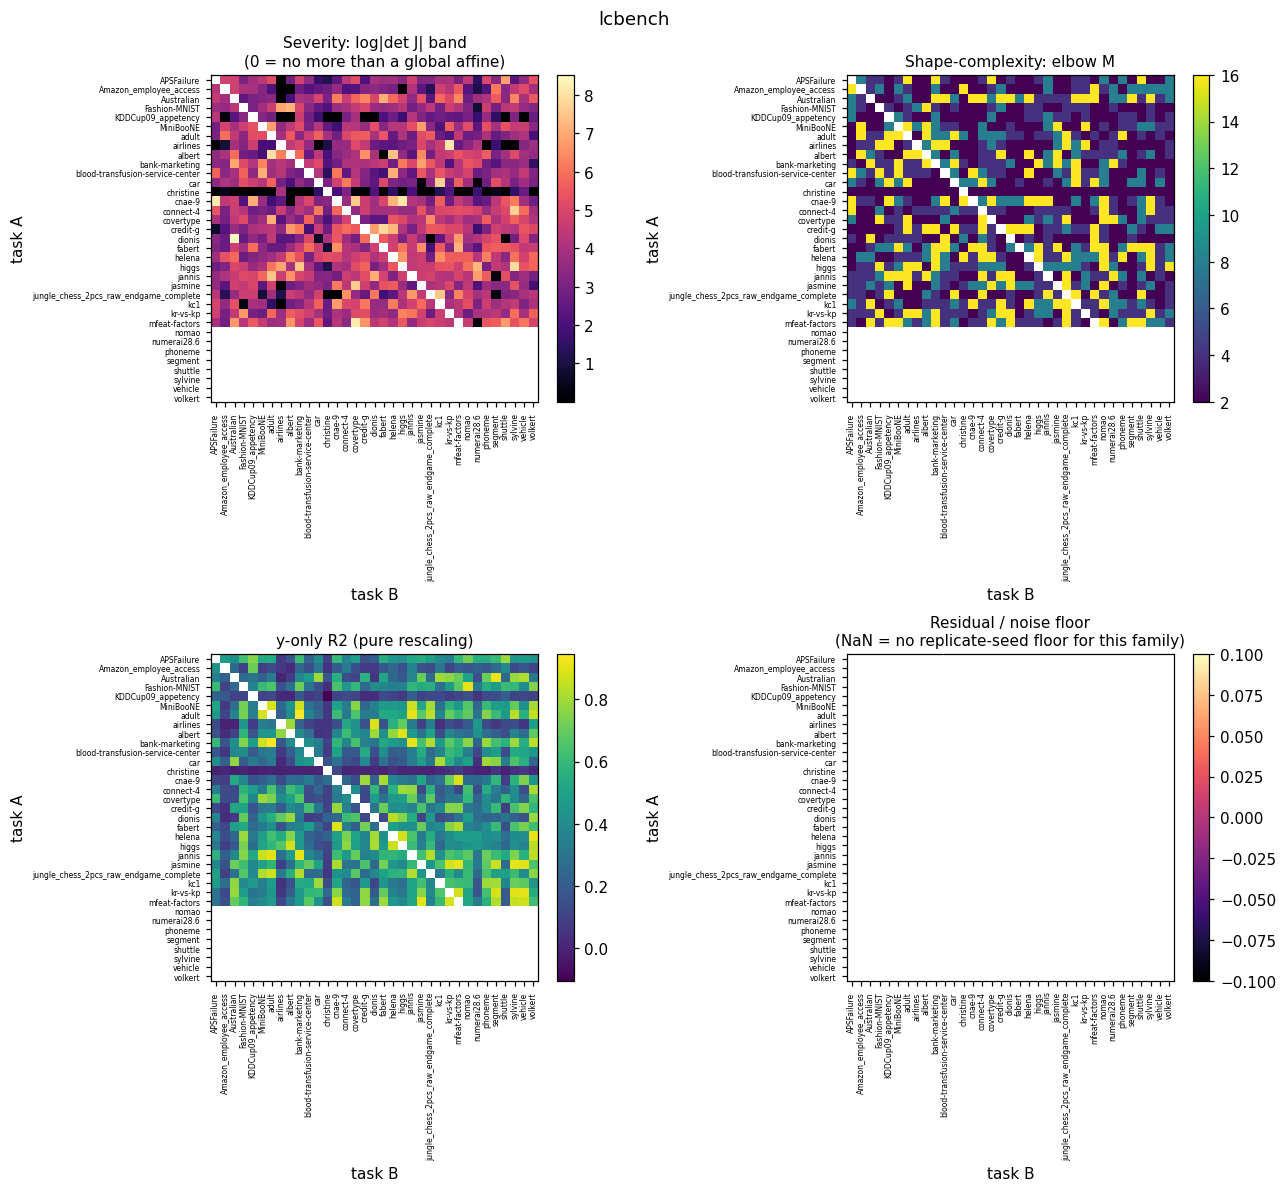

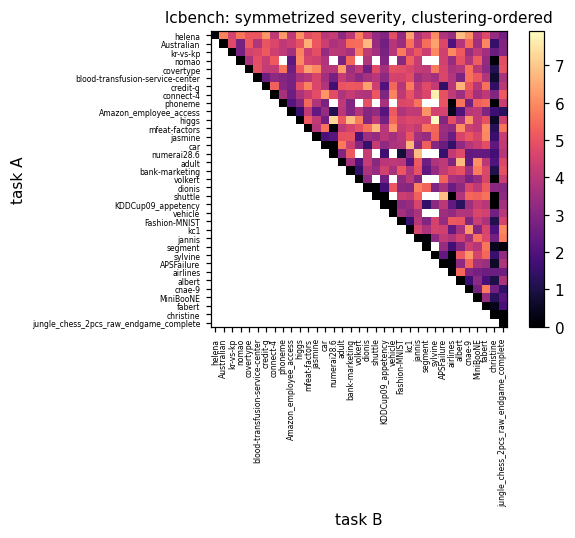

  median y-only R2: 0.382  |  median severity: 3.984  |  median elbow M: 4.0  |  affine-sufficient: 36%
  median fidelity-warp severity |log(tau)|: 0.693  |  median R2 gain from fidelity warp: 0.006
=== lr === 812/812 ordered pairs across 29 tasks (100%)


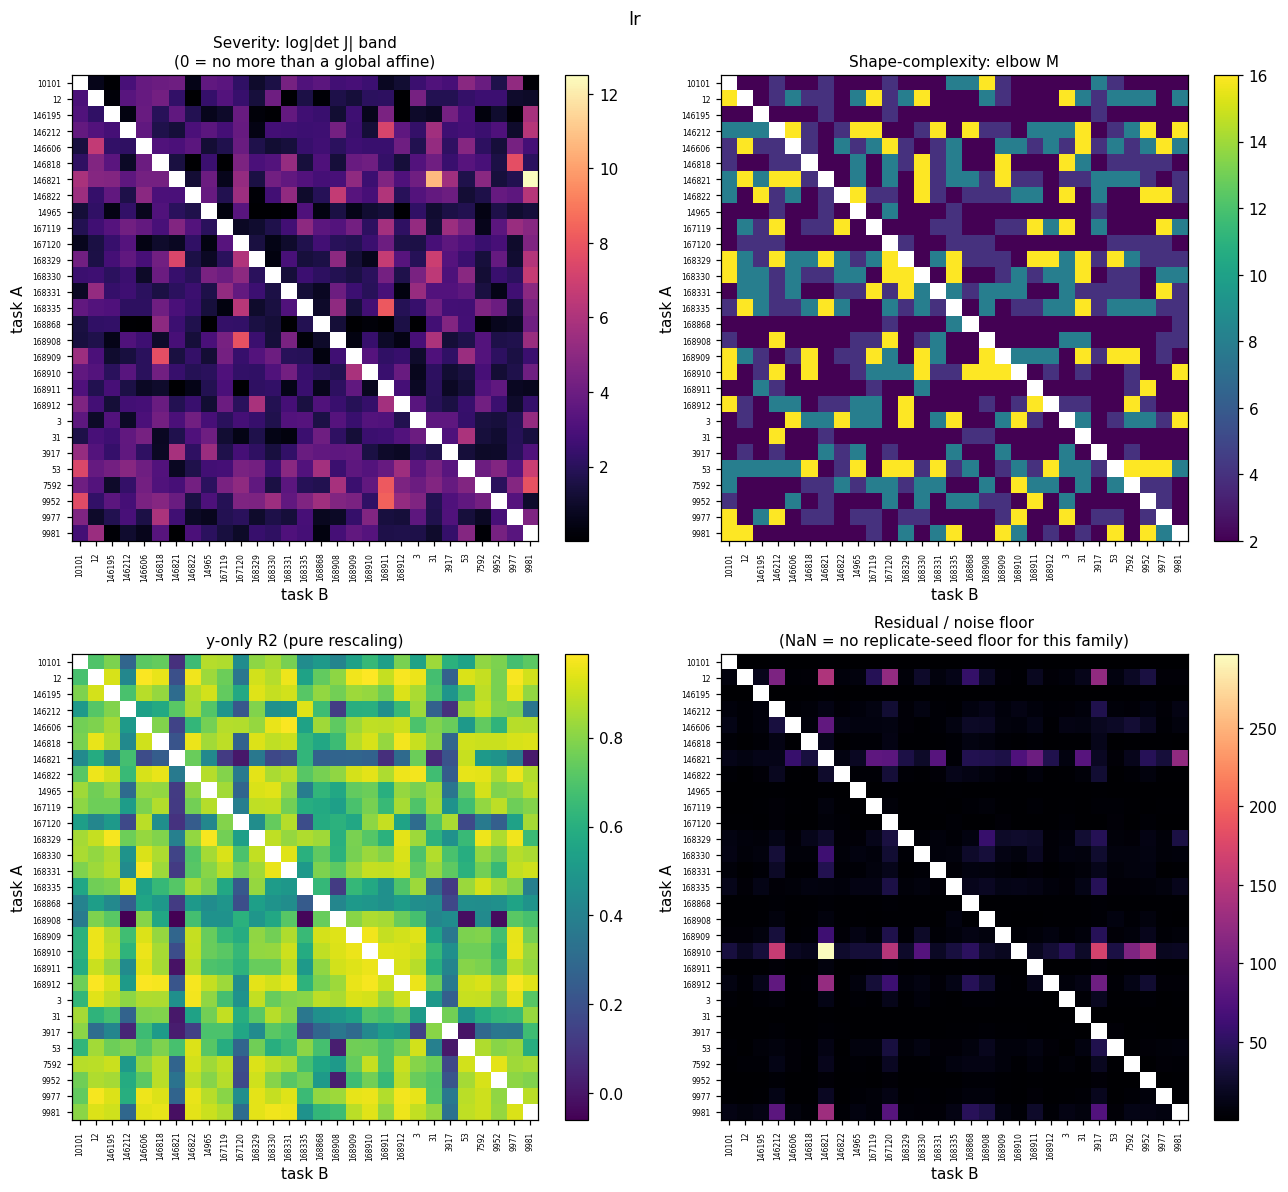

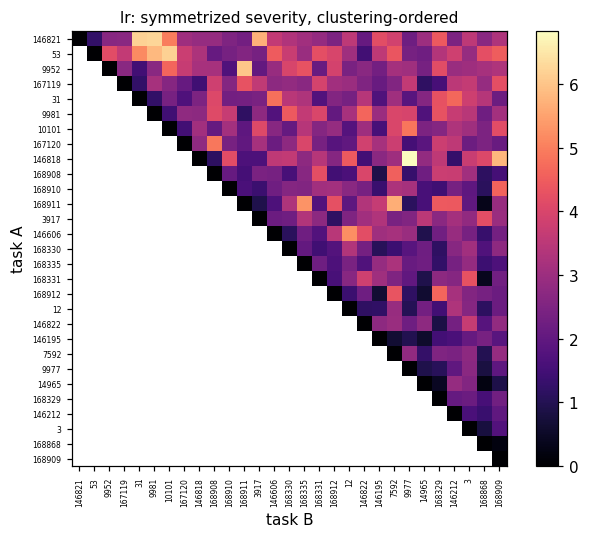

  median y-only R2: 0.764  |  median severity: 2.522  |  median elbow M: 4.0  |  affine-sufficient: 45%
  median residual/noise-floor: 3.10
  median fidelity-warp severity |log(tau)|: 0.693  |  median R2 gain from fidelity warp: 0.028
=== rf === 756/756 ordered pairs across 28 tasks (100%)


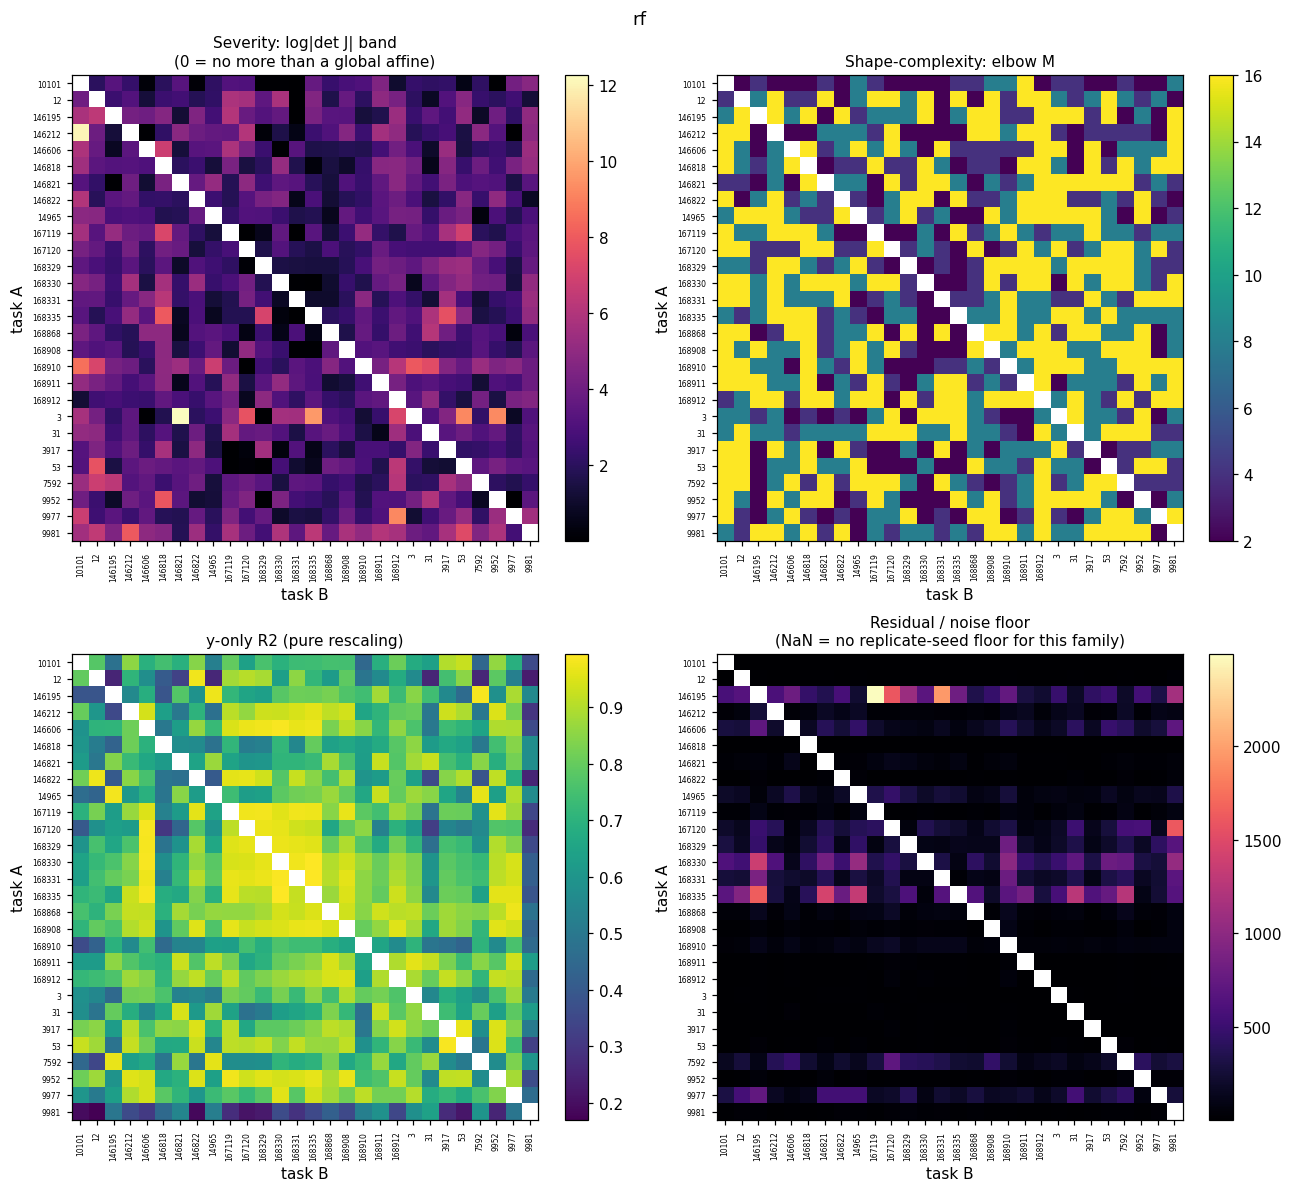

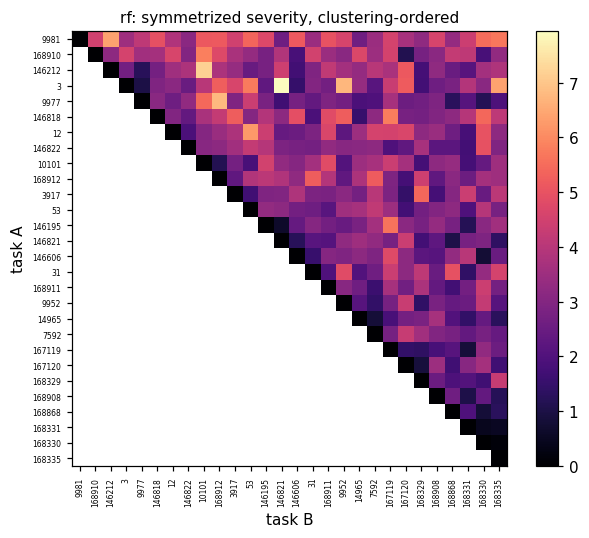

  median y-only R2: 0.764  |  median severity: 3.053  |  median elbow M: 8.0  |  affine-sufficient: 59%
  median residual/noise-floor: 36.79
  median fidelity-warp severity |log(tau)|: 1.155  |  median R2 gain from fidelity warp: 0.002
=== svm === 812/812 ordered pairs across 29 tasks (100%)


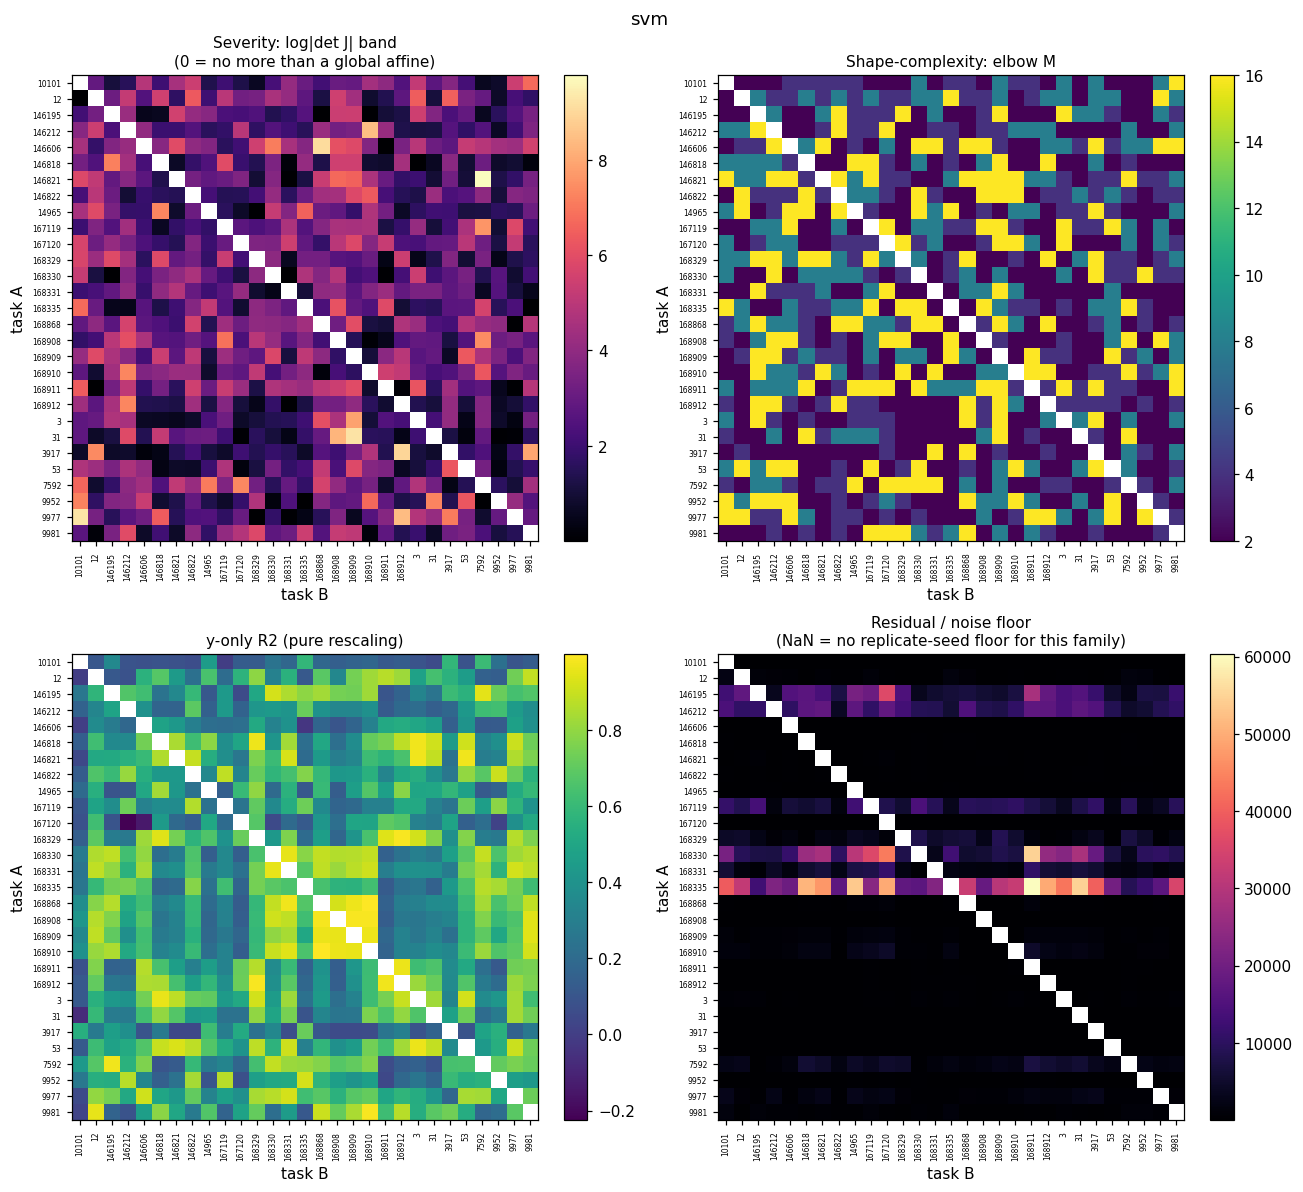

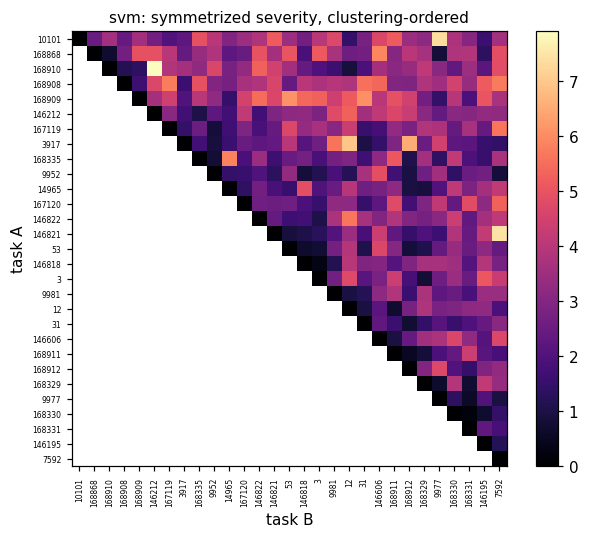

  median y-only R2: 0.498  |  median severity: 2.756  |  median elbow M: 4.0  |  affine-sufficient: 40%
  median residual/noise-floor: 251.75
  median fidelity-warp severity |log(tau)|: 0.000  |  median R2 gain from fidelity warp: 0.000


In [8]:
def build_matrix(frame, col, task_ids):
    idx = {t: i for i, t in enumerate(task_ids)}
    n = len(task_ids)
    mat = np.full((n, n), np.nan)
    for _, row in frame.iterrows():
        a, b = row["task_a"], row["task_b"]
        if a in idx and b in idx:
            mat[idx[a], idx[b]] = row[col]
    return mat


def plot_matrix(mat, task_ids, title, cmap="viridis", ax=None):
    ax = ax or plt.gca()
    im = ax.imshow(mat, cmap=cmap)
    ax.set_xticks(range(len(task_ids)))
    ax.set_xticklabels(task_ids, rotation=90, fontsize=5)
    ax.set_yticks(range(len(task_ids)))
    ax.set_yticklabels(task_ids, fontsize=5)
    ax.set_xlabel("task B")
    ax.set_ylabel("task A")
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
    return im


def symmetrize(mat):
    with np.errstate(invalid="ignore"), warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)  # all-NaN slices: genuinely-not-yet-computed pairs while a sweep is still filling in
        out = np.nanmean(np.stack([mat, mat.T]), axis=0)
    np.fill_diagonal(out, 0.0)  # a task against itself: zero self-distance, by definition, not "unmeasured"
    return out


def cluster_order(sym_mat):
    d = sym_mat.copy()
    finite_max = np.nanmax(d)
    d = np.nan_to_num(d, nan=finite_max)
    np.fill_diagonal(d, 0.0)
    d = (d + d.T) / 2  # guard against asymmetric floating-point noise
    condensed = squareform(d, checks=False)
    z = linkage(condensed, method="average")
    return dendrogram(z, no_plot=True)["leaves"]


def upper_triangular(mat):
    out = mat.copy()
    out[np.tril_indices_from(out, k=-1)] = np.nan
    return out


def report_family(label: str) -> pd.DataFrame:
    df = load_results(str(RESULTS_DIR), model=label)
    all_task_ids = sorted(set(df["task_a"]) | set(df["task_b"]))
    n_possible = len(all_task_ids) * (len(all_task_ids) - 1)
    print(f"=== {label} === {len(df)}/{n_possible} ordered pairs across {len(all_task_ids)} tasks ({len(df) / max(n_possible,1):.0%})")
    if df.empty:
        return df
    seen_tasks = sorted(set(df["task_a"]) | set(df["task_b"]))

    fig, axes = plt.subplots(2, 2, figsize=(12, 11))
    plot_matrix(build_matrix(df, "severity_logdet_band", seen_tasks), seen_tasks,
                "Severity: log|det J| band\n(0 = no more than a global affine)", cmap="magma", ax=axes[0, 0])
    plot_matrix(build_matrix(df, "shape_complexity_m", seen_tasks), seen_tasks,
                "Shape-complexity: elbow M", cmap="viridis", ax=axes[0, 1])
    plot_matrix(build_matrix(df, "y_only_r2", seen_tasks), seen_tasks,
                "y-only R2 (pure rescaling)", cmap="viridis", ax=axes[1, 0])
    plot_matrix(build_matrix(df, "residual_to_noise_floor", seen_tasks), seen_tasks,
                "Residual / noise floor\n(NaN = no replicate-seed floor for this family)", cmap="magma", ax=axes[1, 1])
    fig.suptitle(label)
    fig.tight_layout()
    plt.show()

    sev_sym = symmetrize(build_matrix(df, "severity_logdet_band", seen_tasks))
    if len(seen_tasks) >= 3:
        order = cluster_order(sev_sym)
        ordered_tasks = [seen_tasks[i] for i in order]
        fig, ax = plt.subplots(figsize=(6, 5))
        plot_matrix(upper_triangular(sev_sym[np.ix_(order, order)]), ordered_tasks,
                    f"{label}: symmetrized severity, clustering-ordered", cmap="magma", ax=ax)
        fig.tight_layout()
        plt.show()

    r2_cols = [c for c in df.columns if c.startswith("r2_") and c != "r2_identity"]
    df["best_ladder_r2"] = df[["r2_identity"] + r2_cols].max(axis=1)
    df["affine_sufficient"] = df["r2_affine"] >= 0.95 * df["best_ladder_r2"]
    print(f"  median y-only R2: {df['y_only_r2'].median():.3f}  |  "
          f"median severity: {df['severity_logdet_band'].median():.3f}  |  "
          f"median elbow M: {df['shape_complexity_m'].median():.1f}  |  "
          f"affine-sufficient: {df['affine_sufficient'].mean():.0%}")
    if df["residual_to_noise_floor"].notna().any():
        print(f"  median residual/noise-floor: {df['residual_to_noise_floor'].median():.2f}")
    if "fidelity_log_tau_severity" in df.columns and df["fidelity_log_tau_severity"].notna().any():
        gain = (df["fidelity_r2_at_best_tau"] - df["fidelity_r2_at_tau1"]).median()
        print(f"  median fidelity-warp severity |log(tau)|: {df['fidelity_log_tau_severity'].median():.3f}  |  "
              f"median R2 gain from fidelity warp: {gain:.3f}")
    return df


results_by_family = {label: report_family(label) for label in families}

## Extending this

**More pairs / more families**, on ulysses (shard-per-pair, so this only
computes what's missing):

```bash
ssh ulysses
source ~/hpobench_venv/.venv/bin/activate
cd ~/PycharmProjects/Meta_FTPFN
PYTHONPATH=src python3 -m ppfn.experiments.hpo_warp.run_pairs \
    --family hpobench --model nn --data-dir data/hpobench-tabular --out-dir data/hpo_warp_results --workers 14
PYTHONPATH=src python3 -m ppfn.experiments.hpo_warp.run_pairs \
    --family lcbench --data-dir data/lcbench-tabular --out-dir data/hpo_warp_results --workers 14
# then rsync data/hpo_warp_results back and re-run this notebook
```

**A different metric on an existing fit**, no re-optimization — every rung's
fitted state lives in the `.artifacts.pt` sidecar:

In [9]:
# Round-trip through disk with a fresh, current-format artifact (rather than
# a real on-disk one, which -- per the warning above -- may predate this
# session's h-family fix and be saved under the old schema).
from ppfn.experiments.hpo_warp.artifacts import save_artifacts
demo_artifacts, demo_elbow_vf = synthetic_artifacts["warped"]
save_artifacts(demo_artifacts, "/tmp/demo_artifact.pt")
artifacts, modules = load_artifacts("/tmp/demo_artifact.pt")

print(f"pair: A_warped_and_y_distorted -> B_reference")
print(f"rungs available for re-analysis: {list(modules.keys())}")
print(f"rung used for this notebook's severity/complexity numbers: {artifacts.elbow_rung}")
print(f"h: lambda={artifacts.h_lambda:.3f}, scale={artifacts.h_scale:.3f}, shift={artifacts.h_shift:.3f}")

from ppfn.experiments.hpo_warp.warps import logdet_jacobian_band
max_capacity_rung = "velocity_m16"
band, fold = logdet_jacobian_band(modules[max_capacity_rung], artifacts.d)
print(f"e.g. recompute severity at MAX capacity instead of the elbow:")
print(f"  {max_capacity_rung}: severity={band:.3f}, fold_fraction={fold:.3f}")

# Once the real sweeps are redone with the current method, the same call
# works on any real shard's `.artifacts.pt` file directly:
#   artifacts, modules = load_artifacts(RESULTS_DIR / label / f"{task_a}__{task_b}.artifacts.pt")

pair: A_warped_and_y_distorted -> B_reference
rungs available for re-analysis: ['affine', 'spline_k2', 'spline_k4', 'spline_k8', 'spline_k16', 'velocity_m2', 'velocity_m4', 'velocity_m8', 'velocity_m16']
rung used for this notebook's severity/complexity numbers: velocity_m16
h: lambda=0.000, scale=0.890, shift=0.387
e.g. recompute severity at MAX capacity instead of the elbow:
  velocity_m16: severity=2.174, fold_fraction=0.000
